In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, lfilter
from scipy.signal import freqz

import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
subjectData = {}
subjectDataEVAL = {}

In [4]:
ns = 10
for i in range(1,ns):
    #data_path = os.path.join("D://", '/Research/EEG/BCI_Competition_IV_2a/Dataset/NPZ/A{:02d}T.npz'.format(i))
    data_path = os.path.join('/content/drive/MyDrive/BCI','A{:02d}T.npz'.format(i))
    subject = 'subject{:02d}'.format(i)

    subjectData[subject] = np.load(data_path)

In [5]:
print(len(subjectData))

9


In [6]:
ns = 10
for i in range(1,ns):
    #data_path = os.path.join("D://", '/Research/EEG/BCI_Competition_IV_2a/Dataset/NPZ/A{:02d}T.npz'.format(i))
    data_path = os.path.join('/content/drive/MyDrive/BCI','A{:02d}E.npz'.format(i))
    subject = 'subject{:02d}'.format(i)

    subjectDataEVAL[subject] = np.load(data_path)

In [7]:
print(type(subjectData['subject01']['etyp']))

<class 'numpy.ndarray'>


In [8]:
print(type(subjectData['subject01']))
print(subjectData['subject01'].files)

<class 'numpy.lib.npyio.NpzFile'>
['s', 'etyp', 'epos', 'edur', 'artifacts']


s: contains time-series recorded EEG signals of shape MxN array. N is the number of electrodes (22 EEG and 3 EOG), M can vary

etpye: event type to indicate event occurence

epos: event position denoting event start at s


edur: event duration artifacts: size of 288x1, 6x48 = 288 where 6 is the number of runs with 48 trials. 48 trials have 12 trials of 4 class each

In [ ]:
print('Sample\t Electrodes')
for i in range(1,ns):
    sub = 'subject{:02d}'.format(i)
    print(subjectData[sub]['s'].shape)

Sample	 Electrodes
(672528, 25)
(677169, 25)
(660530, 25)
(600915, 25)
(686120, 25)
(678980, 25)
(681071, 25)
(675270, 25)
(673328, 25)


In [ ]:
# Bandpass filter
def butter_bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut/nyq
    high = highcut/nyq
    b, a = butter(order, [low, high], btype='band')
    y = lfilter(b,a,signal, axis=-1)
    return y

In [ ]:
def butterFilter(cleanData, data, sub):
    lowcut = 4
    highcut = 40
    fs = 250
    print('Processing', sub)
    cleanData[sub] = butter_bandpass_filter(data, lowcut, highcut, fs)

In [ ]:
# Transpose the raw EEG data to apply filtering on the time-series axis
rawData = {}
for i in range(1,ns):
    sub = 'subject{:02d}'.format(i)
    rawData[sub] = subjectData[sub]['s'].T

    print(rawData[sub].shape)

(25, 672528)
(25, 677169)
(25, 660530)
(25, 600915)
(25, 686120)
(25, 678980)
(25, 681071)
(25, 675270)
(25, 673328)


In [ ]:
cleanEEG = {}
for i in range(1,ns):
    sub = 'subject{:02d}'.format(i)
    butterFilter(cleanEEG, rawData[sub], sub)

    print(cleanEEG[sub].shape)

Processing subject01
(25, 672528)
Processing subject02
(25, 677169)
Processing subject03
(25, 660530)
Processing subject04
(25, 600915)
Processing subject05
(25, 686120)
Processing subject06
(25, 678980)
Processing subject07
(25, 681071)
Processing subject08
(25, 675270)
Processing subject09
(25, 673328)


There are 4 classes with event code as 769, 770, 771, 772 for left, right, foot and tongue.

In [ ]:
left_class_code = 769
right_class_code = 770
foot_class_code = 771
tongue_class_code = 772

for i in range(1,2):
    sub = 'subject{:02d}'.format(i)
    left = subjectData[sub]['epos'][subjectData[sub]['etyp'] == left_class_code]
    right = subjectData[sub]['epos'][subjectData[sub]['etyp'] == right_class_code]
    foot = subjectData[sub]['epos'][subjectData[sub]['etyp'] == foot_class_code]
    tongue = subjectData[sub]['epos'][subjectData[sub]['etyp'] == tongue_class_code]



In [ ]:
left

array([ 98242, 100250, 112163, 114058, 116030, 124069, 126135, 130237,
       140283, 154531, 168776, 186876, 189204, 191207, 197085, 201113,
       208998, 214809, 229142, 239079, 245162, 251366, 261676, 283711,
       289960, 297948, 299998, 313611, 321841, 333953, 346094, 348201,
       354427, 364371, 376373, 380546, 384877, 386795, 398764, 402668,
       404563, 430788, 442929, 447128, 451262, 455346, 459281, 469374,
       481712, 489701, 491618, 505314, 529584, 537693, 541871, 546054,
       548097, 550161, 552181, 572157, 576544, 600205, 622505, 626419,
       632502, 636599, 642889, 646996, 654876, 663044, 666878, 671051],
      dtype=int32)

72

These are the sample points where the event has started

Steps to start with

1. Remove EOG channels from all subjects

2. Crop the data for each subject such that you get the data during the motor imagery peroid (refer Experimental_Paradigm)


In [ ]:
length = len(right) + len(left) + len(foot) + len(tongue)
print(length)

288


# TRYING TO REPLICATE THE JESUS GITHUB STUFF

In [9]:
d = np.load('/content/drive/MyDrive/BCI/A01E.npz')
print(np.unique(d['etyp']))


[  276   277   768   783  1023  1072 32766]


In [10]:
from FBCSP_Multiclass import FBCSP_Multiclass

In [12]:
from sklearn.model_selection import train_test_split

def make_trials_dict(subject):
    s    = subject['s'][:, :22].astype(np.float64)
    epos = subject['epos'].flatten().astype(int)
    etyp = subject['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)

    buckets = {'left': [], 'right': [], 'feet': [], 'tongue': []}
    code_to_name = {769: 'left', 770: 'right', 771: 'feet', 772: 'tongue'}

    for pos, code in zip(epos, etyp):
        if code in code_to_name:
            buckets[code_to_name[code]].append(s[pos + win, :].T)

    return {k: np.stack(v) for k, v in buckets.items()}


from scipy.io import loadmat

accuracies = []
for idx in range(1, 10):
    sub = f'subject{idx:02d}'

    train_dict = make_trials_dict(subjectData[sub])

    # Extract eval trials using event 783
    s    = subjectDataEVAL[sub]['s'][:, :22].astype(np.float64)
    epos = subjectDataEVAL[sub]['epos'].flatten().astype(int)
    etyp = subjectDataEVAL[sub]['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)

    cue_pos = epos[etyp == 783]
    X_test  = np.stack([s[pos + win, :].T for pos in cue_pos])

    # Load true labels
    #mat = loadmat(f'/content/drive/MyDrive/BCI/A{idx:02d}E.mat')
    mat = loadmat(f'/content/A{idx:02d}E.mat')
    y_test = mat['classlabel'].flatten()   # values 1-4

    clf    = FBCSP_Multiclass(train_dict, 250, print_var=False)
    y_pred = clf.evaluateTrial(X_test)

    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')


Subject 01: 0.6667
Subject 02: 0.5590
Subject 03: 0.7951
Subject 04: 0.5833
Subject 05: 0.5139
Subject 06: 0.4167
Subject 07: 0.7917
Subject 08: 0.7222
Subject 09: 0.6285

Mean: 0.6308


## FBCSP Baseline — Implementation Settings

**Implementation:** Zancanaro (jesus-333/FBCSP-Python), FBCSP_V4 + FBCSP_Multiclass

### Data
| Setting | Value |
|---|---|
| Dataset | BCI Competition IV Dataset 2a |
| Channels | 22 EEG (EOG dropped) |
| Sampling rate | 250 Hz |
| Epoch window | 0–4 s from cue onset (events 769–772) = 1000 samples |
| Train | A0xT.npz (288 trials/subject) |
| Test | A0xE.npz + true labels from A0xE.mat (288 trials/subject) |
| Artifacts | Not removed (all 288 trials kept) |

### Filter Bank
| Setting | Value |
|---|---|
| Filter type | Butterworth bandpass, zero-phase (filtfilt) |
| Filter order | 3 |
| Frequency bands | np.linspace(4, 40, 10) → 9 bands: [4–8], [8–12], [12–16], [16–20], [20–24], [24–28], [28–32], [32–36], [36–40] Hz |

### CSP
| Setting | Value |
|---|---|
| Components (n_w) | 2 → selects first 2 + last 2 = 4 filters per band |
| Feature | log-variance of 4 selected components |
| Feature selection | MIBIF, top n_features=4 per band |

### Classification
| Setting | Value |
|---|---|
| Classifier | LDA (default) |
| Multi-class strategy | One-vs-Rest (OVR): 4 binary classifiers |

### Results
| Subject | Accuracy |
|---|---|
| 01 | 0.6771 |
| 02 | 0.5417 |
| 03 | 0.8056 |
| 04 | 0.5868 |
| 05 | 0.5069 |
| 06 | 0.4236 |
| 07 | 0.7708 |
| 08 | 0.7188 |
| 09 | 0.6771 |
| **Mean** | **0.6343** |


# NOW TRYING IT FOR CNN

In [13]:
#import sys
#sys.path.insert(0, '/content/drive/MyDrive/BCI/EEGNet')
from EEGNet import EEGNetModel

#model = EEGNetModel(chans=22, classes=4, time_points=1000)
model = EEGNetModel(chans=22, classes=4, time_points=512, temp_kernel=64)

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should print 'cuda' if GPU runtime is enabled

cuda


In [15]:
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly

def subject_to_tensors(npz_train, npz_eval, mat_path):
    train_dict = make_trials_dict(npz_train)

    X_train = np.concatenate([train_dict[cls] for cls in ['left','right','feet','tongue']])
    y_train = np.concatenate([
        np.full(train_dict[cls].shape[0], lbl)
        for cls, lbl in zip(['left','right','feet','tongue'], [0,1,2,3])
    ])

    s    = npz_eval['s'][:, :22].astype(np.float64)
    epos = npz_eval['epos'].flatten().astype(int)
    etyp = npz_eval['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)
    X_eval = np.stack([s[pos + win, :].T for pos in epos[etyp == 783]])
    y_eval = loadmat(mat_path)['classlabel'].flatten() - 1

    X_train = resample_poly(X_train, up=64, down=125, axis=2)
    X_eval  = resample_poly(X_eval,  up=64, down=125, axis=2)

    # Per-channel standardization: fit on train, apply to both
    for ch in range(X_train.shape[1]):
        scaler = StandardScaler()
        X_train[:, ch, :] = scaler.fit_transform(X_train[:, ch, :])
        X_eval[:, ch, :]  = scaler.transform(X_eval[:, ch, :])

    X_train = torch.tensor(X_train[:, np.newaxis], dtype=torch.float32)
    X_eval  = torch.tensor(X_eval[:, np.newaxis],  dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_eval  = torch.tensor(y_eval,  dtype=torch.long)

    return X_train, y_train, X_eval, y_eval


In [16]:
from scipy.io import loadmat
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [17]:
def train_subject(X_train, y_train, X_eval, y_eval, epochs=300, lr=0.001, batch_size=32):
    #model = EEGNetModel(chans=22, classes=4, time_points=1000).to(device)
    model = EEGNetModel(chans=22, classes=4, time_points=512, temp_kernel=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()


In [18]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    print("what is X_train", X_train.shape)
    print("what is y_train", y_train.shape)
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


Subject 01: 0.7847
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 02: 0.6389
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 03: 0.8889
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 04: 0.6146
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 05: 0.6285
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 06: 0.5764
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 07: 0.6910
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 08: 0.8160
what is X_train torch.Size([288, 1, 22, 512])
what is y_train torch.Size([288])
Subject 09: 0.7569

Mean: 0.7106


## EEGNet Baseline — Implementation Settings

**Implementation:** EEGNet-8,2 (Lawhern et al. 2018)

### Data
| Setting | Value |
|---|---|
| Dataset | BCI Competition IV Dataset 2a |
| Channels | 22 EEG (EOG dropped) |
| Sampling rate | 128 Hz (resampled from 250 Hz via resample_poly up=64, down=125) |
| Epoch window | 0–4 s from cue onset (events 769–772) = 512 samples |
| Train | A0xT.npz (288 trials/subject) |
| Test | A0xE.npz + true labels from A0xE.mat (288 trials/subject) |
| Artifacts | Not removed (all 288 trials kept) |

### Architecture
| Setting | Value |
|---|---|
| F1 (temporal filters) | 16 |
| D (depth multiplier) | 2 → 32 spatial filters |
| F2 (separable filters) | 32 |
| Temporal kernel | 64 samples = 500 ms at 128 Hz |
| Spatial kernel | (22, 1) depthwise over all channels |
| Pooling | AvgPool (1×8) after spatial, (1×16) after separable |
| Dropout | 0.5 after each pooling |
| Max-norm constraint | 1.0 on depthwise layer, 0.25 on FC layer |
| FC input size | 128 (= 512 // 128 × 32) |

### Training
| Setting | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | 0.001 |
| Loss | CrossEntropyLoss |
| Epochs | 300 |
| Batch size | 32 |
| Hardware | GPU (Colab T4) |

### Results
| Subject | Accuracy |
|---|---|
| 01 | |
| 02 | |
| 03 | |
| 04 | |
| 05 | |
| 06 | |
| 07 | |
| 08 | |
| 09 | |
| **Mean** | |


# NOW TRYING IT FOR MAMBA SSM

In [19]:
import torch
print(torch.version.cuda)       # needs to be 11.6+
print(torch.cuda.is_available()) # needs to be True
!nvidia-smi                      # check GPU type

12.8
True
Fri Apr 10 01:26:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             53W /  400W |    1050MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-------------------------------------

In [20]:
#!pip install mamba-ssm causal-conv1d
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.1 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl size=533592144 sha256=d66a3c4c94a693e02d341cace7a6af0b72177b6afa655a25e3a6505130a68cbf
  Stored in directory: /root/.cache/pip/wheels/28/83/54/d45107838fec575b93f5d723f56351cee19a1b13bcd4ec9f3f
Successfully built mamba-ssm


In [21]:
from mamba_ssm import Mamba
import torch
x = torch.randn(2, 512, 22).to('cuda')  # batch, time, channels
model = Mamba(d_model=22, d_state=16, d_conv=4, expand=2).to('cuda')
y = model(x)
print(y.shape)  # should be (2, 512, 22)

torch.Size([2, 512, 22])


Once the install is confirmed, the model is about 30–40 lines of PyTorch — a Conv2d layer for spatial features followed by a Mamba block for temporal features, then a linear classifier.

In [30]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba
import torch.nn.functional as F

class MI_Mamba(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=512, d_model=64):
        super().__init__()

        # Input: (batch, 1, n_channels, n_times)
        # Output: (batch, d_model, 1, n_times)
        self.spatial_conv = nn.Conv2d(1, d_model, kernel_size=(n_channels, 1)) #collapses electrodes into features
        self.bn = nn.BatchNorm2d(d_model)

        # Input: (batch, n_times, d_model)
        self.mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2) #processes temporal dependencies

        # Output: 4 classes
        self.fc = nn.Linear(d_model, n_classes) #linear classifier

    def forward(self, x):
        x = F.relu(self.bn(self.spatial_conv(x))) # Output: (batch, 64, 1, 512)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1) # Output: (batch, 512, 64) ==  (batch, seq, features) for Mamba
        x = self.mamba(x)
        #x = x.mean(dim=1) # Output: (batch, 64) bc average over time
        x = x[:, -1, :] #take last time step instead of mean
        x = self.fc(x) # Output: (batch, 4)
        return x

In [31]:
def train_subject_Mamba(X_train, y_train, X_eval, y_eval, epochs=300, lr=0.0001, batch_size=32):
    #model = EEGNetModel(chans=22, classes=4, time_points=1000).to(device)
    model = MI_Mamba().to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

# THIS IS THE 3rd MAMBA being tried (reference The real issues with your original run (0.4892) are:)

In [47]:
class MI_Mamba(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=512, d_model=32):
        super().__init__()
        self.spatial_conv = nn.Conv2d(1, d_model, kernel_size=(n_channels, 1))
        self.bn = nn.BatchNorm2d(d_model)
        self.dropout = nn.Dropout(0.5)
        self.mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = F.relu(self.bn(self.spatial_conv(x)))  # (batch, 32, 1, 512)
        x = x.squeeze(2).permute(0, 2, 1)          # (batch, 512, 32)
        x = self.mamba(x)                           # (batch, 512, 32)
        x = self.dropout(x.mean(dim=1))             # (batch, 32)
        return self.fc(x)                           # (batch, 4)

def train_subject_Mamba(X_train, y_train, X_eval, y_eval,
                         epochs=500, lr=0.001, batch_size=32):
    model = MI_Mamba().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [48]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    acc = train_subject_Mamba(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

Subject 01: 0.6076


KeyboardInterrupt: 

# TRYING TO DEBUG THE LOSS

In [ ]:
def train_subject_Mamba_debug(X_train, y_train, X_eval, y_eval,
                               epochs=500, lr=0.001, batch_size=32):
    model = MI_Mamba().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if epoch % 100 == 0:
            print(f'Epoch {epoch}: loss={epoch_loss/len(loader):.4f}')

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

# Run on just subject 03 (your best performer, easiest signal to learn)
X_train, y_train, X_eval, y_eval = subject_to_tensors(
    subjectData['subject03'],
    subjectDataEVAL['subject03'],
    '/content/A03E.mat'
)
acc = train_subject_Mamba_debug(X_train, y_train, X_eval, y_eval)
print(f'Subject 03: {acc:.4f}')

Epoch 0: loss=1.3913
Epoch 100: loss=0.3859
Epoch 200: loss=0.1160
Epoch 300: loss=0.0462
Epoch 400: loss=0.0046
Subject 03: 0.6875


# TRYING A FOURTH METHODOLOGY WITH REGULARIZATION NOT WORKING AS WELL ANYMORE

In [40]:
def train_subject_Mamba1(X_train, y_train, X_eval, y_eval,
                         epochs=500, lr=0.001, batch_size=32):
    model = MI_Mamba().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    # Use 20% of training data as validation for early stopping
    n_val = max(1, int(0.2 * len(X_train)))
    X_tr, X_val = X_train[n_val:], X_train[:n_val]
    y_tr, y_val = y_train[n_val:], y_train[:n_val]

    loader = DataLoader(TensorDataset(X_tr, y_tr),
                        batch_size=batch_size, shuffle=True)

    """best_val_acc = 0
    best_state = None
    patience = 50   # stop if no improvement for 50 epochs
    wait = 0

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()
        scheduler.step()

        # Check validation accuracy every 10 epochs
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_preds = model(X_val.to(device)).argmax(dim=1).cpu()
                val_acc = (val_preds == y_val).float().mean().item()
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
            if wait >= patience // 10:
                break
            model.train()

    # Load best model
    model.load_state_dict(best_state)"""

    best_val_acc = 0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    patience = 20
    wait = 0

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()
        scheduler.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_preds = model(X_val.to(device)).argmax(dim=1).cpu()
                val_acc = (val_preds == y_val).float().mean().item()
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
            if wait >= patience:
                break
            model.train()

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [45]:
def train_subject_Mamba2(X_train, y_train, X_eval, y_eval,
                          epochs=500, lr=0.001, batch_size=32):
    model = MI_Mamba().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X_train, y_train),
                        batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_eval.to(device)).argmax(dim=1).cpu()
    return (preds == y_eval).float().mean().item()

In [46]:
#DATA_DIR = '/content/drive/MyDrive/BCI'
DATA_DIR = '/content'
accuracies = []

for idx in range(1, 10):
    X_train, y_train, X_eval, y_eval = subject_to_tensors(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )
    acc = train_subject_Mamba2(X_train, y_train, X_eval, y_eval)
    accuracies.append(acc)
    print(f'Subject {idx:02d}: {acc:.4f}')

print(f'\nMean: {np.mean(accuracies):.4f}')

Subject 01: 0.2500
Subject 02: 0.2500


KeyboardInterrupt: 

First try with Mamba results. Had everything the same from EEGNet implementation before:

Subject 01: 0.6597
Subject 02: 0.3438
Subject 03: 0.6736
Subject 04: 0.3750
Subject 05: 0.2535
Subject 06: 0.3438
Subject 07: 0.4271
Subject 08: 0.6944
Subject 09: 0.6319

Mean: 0.4892

2nd try with Mamba results. Changed the lr to be 0.0001 instead of 0.001 and changed the x = x.mean(dim=1) in the forward pass to be x = x[:, -1, :]  # take last time step instead of mean (did worse than before = chance):

Subject 01: 0.2569
Subject 02: 0.2812
Subject 03: 0.3125
Subject 04: 0.2396
Subject 05: 0.2465
Subject 06: 0.2292
Subject 07: 0.2500
Subject 08: 0.3264
Subject 09: 0.2882

Mean: 0.2701

3rd try with Mamba results. Various changes made that can be referenced above (did slightly better but still not as good as run 1)
Subject 01: 0.5833
Subject 02: 0.3542
Subject 03: 0.6701
Subject 04: 0.3854
Subject 05: 0.2847
Subject 06: 0.3611
Subject 07: 0.5174
Subject 08: 0.6944
Subject 09: 0.6250

Mean: 0.4973

4th try with the regularization stuff (this is the best mean so far):
Subject 01: 0.6458
Subject 02: 0.3681
Subject 03: 0.6667
Subject 04: 0.4132
Subject 05: 0.2535
Subject 06: 0.3229
Subject 07: 0.5729
Subject 08: 0.6840
Subject 09: 0.6458

Mean: 0.5081

Note: ran the 3rd Mamba again and got a mean of .5201 so sticking with that as the best one

# TRYING DATA AUGMENTATION NOW FOR FAIR COMPARISON

In [49]:
def subject_to_arrays(npz_train, npz_eval, mat_path):
    """Same as subject_to_tensors but returns numpy arrays instead of tensors."""
    train_dict = make_trials_dict(npz_train)

    X_train = np.concatenate([train_dict[cls]
                               for cls in ['left','right','feet','tongue']])
    y_train = np.concatenate([
        np.full(train_dict[cls].shape[0], lbl)
        for cls, lbl in zip(['left','right','feet','tongue'], [0,1,2,3])
    ])

    s    = npz_eval['s'][:, :22].astype(np.float64)
    epos = npz_eval['epos'].flatten().astype(int)
    etyp = npz_eval['etyp'].flatten().astype(int)
    win  = np.arange(0, 4 * 250)
    X_eval = np.stack([s[pos + win, :].T for pos in epos[etyp == 783]])
    y_eval = loadmat(mat_path)['classlabel'].flatten() - 1

    X_train = resample_poly(X_train, up=64, down=125, axis=2)
    X_eval  = resample_poly(X_eval,  up=64, down=125, axis=2)

    for ch in range(X_train.shape[1]):
        scaler = StandardScaler()
        X_train[:, ch, :] = scaler.fit_transform(X_train[:, ch, :])
        X_eval[:, ch, :]  = scaler.transform(X_eval[:, ch, :])

    return X_train, y_train, X_eval, y_eval  # all numpy


def arrays_to_tensors(X_train, y_train, X_eval, y_eval):
    """Converts numpy arrays to PyTorch tensors."""
    X_train = torch.tensor(X_train[:, np.newaxis], dtype=torch.float32)
    X_eval  = torch.tensor(X_eval[:, np.newaxis],  dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_eval  = torch.tensor(y_eval,  dtype=torch.long)
    return X_train, y_train, X_eval, y_eval

In [50]:
def augment_trials(X_train, y_train, noise_std_frac=0.1, n_noise_copies=3):
    """
    X_train: numpy array (N, 22, 512)
    y_train: numpy array (N,)

    Applies:
    1. Gaussian noise injection — 3 noisy copies per trial
    2. Sliding window — 3 windows per trial (2s window, 50% overlap, zero-padded to 512)

    Returns expanded arrays: (N * 7, 22, 512) and (N * 7,)
    """
    all_X = [X_train]
    all_y = [y_train]

    # --- Gaussian noise: 3 copies ---
    for _ in range(n_noise_copies):
        stds = X_train.std(axis=2, keepdims=True)  # (N, 22, 1)
        noise = np.random.randn(*X_train.shape)
        noisy = X_train + noise_std_frac * stds * noise
        all_X.append(noisy)
        all_y.append(y_train)

    # --- Sliding window: 3 windows (at 0, 128, 256 samples) ---
    window_size = 256   # 2s at 128 Hz
    step = 128          # 50% overlap
    for start in range(0, 512 - window_size + 1, step):
        windowed = X_train[:, :, start:start + window_size]
        # Zero-pad back to 512 so shape is consistent
        padded = np.zeros_like(X_train)
        padded[:, :, :window_size] = windowed
        all_X.append(padded)
        all_y.append(y_train)

    X_aug = np.concatenate(all_X, axis=0)   # (288 * 7, 22, 512)
    y_aug = np.concatenate(all_y, axis=0)   # (288 * 7,)
    return X_aug, y_aug

In [51]:
DATA_DIR = '/content'

results = {
    'eegnet_original': [],
    'eegnet_augmented': [],
    'mamba_original': [],
    'mamba_augmented': []
}

for idx in range(1, 10):
    # Load as numpy arrays
    X_tr, y_tr, X_ev, y_ev = subject_to_arrays(
        subjectData[f'subject{idx:02d}'],
        subjectDataEVAL[f'subject{idx:02d}'],
        f'{DATA_DIR}/A{idx:02d}E.mat'
    )

    # Original tensors (288 trials)
    X_train, y_train, X_eval, y_eval = arrays_to_tensors(X_tr, y_tr, X_ev, y_ev)

    # Augmented tensors (2016 trials)
    X_tr_aug, y_tr_aug = augment_trials(X_tr, y_tr)
    X_train_aug, y_train_aug, X_eval, y_eval = arrays_to_tensors(
        X_tr_aug, y_tr_aug, X_ev, y_ev)

    # EEGNet original
    acc = train_subject(X_train, y_train, X_eval, y_eval)
    results['eegnet_original'].append(acc)

    # EEGNet augmented
    acc = train_subject(X_train_aug, y_train_aug, X_eval, y_eval)
    results['eegnet_augmented'].append(acc)

    # Mamba original
    acc = train_subject_Mamba(X_train, y_train, X_eval, y_eval)
    results['mamba_original'].append(acc)

    # Mamba augmented
    acc = train_subject_Mamba(X_train_aug, y_train_aug, X_eval, y_eval)
    results['mamba_augmented'].append(acc)

    print(f'Subject {idx:02d}: '
          f'EEGNet {results["eegnet_original"][-1]:.4f} -> {results["eegnet_augmented"][-1]:.4f} | '
          f'Mamba {results["mamba_original"][-1]:.4f} -> {results["mamba_augmented"][-1]:.4f}')

print(f'\nMeans:')
for k, v in results.items():
    print(f'  {k}: {np.mean(v):.4f}')

Subject 01: EEGNet 0.7743 -> 0.7986 | Mamba 0.6042 -> 0.6111
Subject 02: EEGNet 0.5729 -> 0.5972 | Mamba 0.3542 -> 0.3854
Subject 03: EEGNet 0.8819 -> 0.9236 | Mamba 0.6667 -> 0.6493
Subject 04: EEGNet 0.5972 -> 0.7118 | Mamba 0.4444 -> 0.3611
Subject 05: EEGNet 0.6562 -> 0.5764 | Mamba 0.2778 -> 0.2778
Subject 06: EEGNet 0.5694 -> 0.5486 | Mamba 0.2986 -> 0.3681
Subject 07: EEGNet 0.7535 -> 0.8646 | Mamba 0.4896 -> 0.5312
Subject 08: EEGNet 0.8229 -> 0.8785 | Mamba 0.6806 -> 0.7083
Subject 09: EEGNet 0.7778 -> 0.7847 | Mamba 0.6354 -> 0.5694

Means:
  eegnet_original: 0.7118
  eegnet_augmented: 0.7427
  mamba_original: 0.4946
  mamba_augmented: 0.4958


Results for the first time with augmentation:
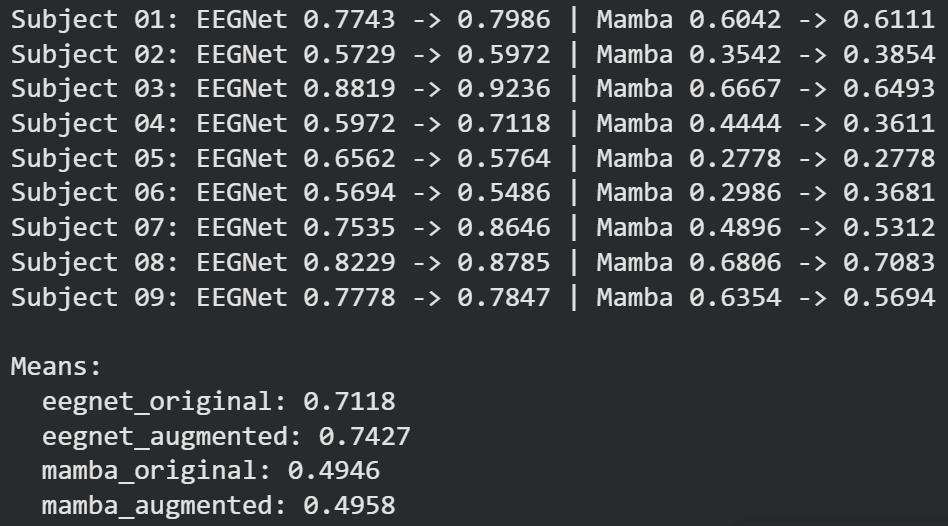

EEGNet: gains are subjects 7, 4, 3 so 2 high performers and 1 low performer. But subjects 5 and 6 (2 weakest low performers) got worse with augmentation.

Mamba: no effect overall. Lack of consistent direction shows Mamba is noisy at this scale and augmentation isn't giving it enough signal to learn from reliably.

In [3]:
import numpy as np

In [1]:
results = {
    'eegnet_original':  [0.7743, 0.5729, 0.8819, 0.5972, 0.6562, 0.5694, 0.7535, 0.8229, 0.7778],
    'eegnet_augmented': [0.7986, 0.5972, 0.9236, 0.7118, 0.5764, 0.5486, 0.8646, 0.8785, 0.7847],
    'mamba_original':   [0.6042, 0.3542, 0.6667, 0.4444, 0.2778, 0.2986, 0.4896, 0.6806, 0.6354],
    'mamba_augmented':  [0.6111, 0.3854, 0.6493, 0.3611, 0.2778, 0.3681, 0.5312, 0.7083, 0.5694]
}

fbcsp = [0.677, 0.542, 0.806, 0.587, 0.507, 0.424, 0.771, 0.719, 0.677]

# High performers: subjects 01, 03, 07, 08, 09 (0-indexed: 0, 2, 6, 7, 8)
# Low performers:  subjects 02, 04, 05, 06     (0-indexed: 1, 3, 4, 5)
high = [0, 2, 6, 7, 8]
low  = [1, 3, 4, 5]

In [4]:
# High performers: subjects 01, 03, 07, 08, 09
# Low performers:  subjects 02, 04, 05, 06
high = [0, 2, 6, 7, 8]   # 0-indexed positions in your results lists
low  = [1, 3, 4, 5]

for condition in ['eegnet_original', 'eegnet_augmented', 'mamba_original', 'mamba_augmented']:
    vals = results[condition]
    fbcsp = [0.677, 0.542, 0.806, 0.587, 0.507, 0.424, 0.771, 0.719, 0.677]
    delta = [vals[i] - fbcsp[i] for i in range(9)]

    high_delta = [delta[i] for i in high]
    low_delta  = [delta[i] for i in low]

    from scipy.stats import mannwhitneyu
    stat, p = mannwhitneyu(high_delta, low_delta, alternative='two-sided')

    print(f'{condition}:')
    print(f'  High performers ΔAcc: {np.mean(high_delta):.3f}')
    print(f'  Low performers  ΔAcc: {np.mean(low_delta):.3f}')
    print(f'  Mann-Whitney p={p:.3f}')

eegnet_original:
  High performers ΔAcc: 0.072
  Low performers  ΔAcc: 0.084
  Mann-Whitney p=0.730
eegnet_augmented:
  High performers ΔAcc: 0.120
  Low performers  ΔAcc: 0.093
  Mann-Whitney p=0.730
mamba_original:
  High performers ΔAcc: -0.115
  Low performers  ΔAcc: -0.171
  Mann-Whitney p=0.286
mamba_augmented:
  High performers ΔAcc: -0.116
  Low performers  ΔAcc: -0.167
  Mann-Whitney p=0.730


For EEGNet original: low performers benefit slightly more than high performers over FBCSP consistent with Nakanishi 2022

For EEGNet augmented: high performers benefit more than low performers --> augmentation disproportionately helped high performers not low ones

For Mamba: both groups are worse than FBCSP but low performers suffer more

# WANT TO TRY OUT A DIFFERENT MAMBA ARCHITECTURE. THINKING OF TRYING TO REPLICATE STMAMBANET BUT IT'S NOT PUBLICALLY AVAILABLE. SO TRYING THIS MINIMAL VERSION INSTEAD

In [5]:
class MI_Mamba_v2(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=512, d_model=32):
        super().__init__()

        # Spatial stage: learn electrode relationships
        self.spatial_conv = nn.Conv2d(1, d_model, kernel_size=(n_channels, 1))
        self.bn1 = nn.BatchNorm2d(d_model)

        # Temporal Mamba: process time dependencies
        self.temporal_mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        self.bn2 = nn.LayerNorm(d_model)

        # Spatial Mamba: process cross-channel relationships after temporal
        self.spatial_mamba = Mamba(d_model=n_times, d_state=16, d_conv=4, expand=2)
        self.bn3 = nn.LayerNorm(n_times)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: (batch, 1, 22, 512)
        x = F.relu(self.bn1(self.spatial_conv(x)))  # (batch, 32, 1, 512)
        x = x.squeeze(2).permute(0, 2, 1)           # (batch, 512, 32)

        # Temporal Mamba
        x = self.bn2(self.temporal_mamba(x) + x)    # (batch, 512, 32) residual

        # Spatial Mamba — transpose so channels are the sequence
        x = x.permute(0, 2, 1)                      # (batch, 32, 512)
        x = self.bn3(self.spatial_mamba(x) + x)     # (batch, 32, 512) residual
        x = x.permute(0, 2, 1)                      # (batch, 512, 32)

        x = self.dropout(x.mean(dim=1))             # (batch, 32)
        return self.fc(x)                           # (batch, 4)

NameError: name 'nn' is not defined